<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_005_clustering/02_DBSCAN_WISDM_2026_09_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBScan usando Datos de acelerómetro y giroscopio por actividades basado en el dataset WISDM

Datos tomados de:

WISDM Smartphone and Smartwatch Activity and Biometrics Dataset

https://archive-beta.ics.uci.edu/dataset/507/wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset

Para el propósito de este ejercicio, se usan los datos de una sola muestra, la 1603, con acelerómetro y giroscopio, tanto del teléfono como del reloj

Eduardo Zurek, Ph.D.

Inteligencia Artificial

Departamento de Ingeniría de Sistemas

Universidad del Norte

## Instalación de las librerías requeridas

In [15]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import scipy as sp
except ImportError:
    %pip install scipy
    import scipy as sp
try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    %pip install seaborn
    import seaborn as sns
try:
    import sklearn as skl
except ImportError:
    %pip install scikit-learn
    import sklearn as skl

## Carga de los datos

In [ ]:
# Esta celda debe ejecutarse solamente una vez
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_accel_phone.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_accel_watch.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_gyro_phone.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_gyro_watch.arff

## Curado de los datos

In [17]:
data_accel_phone, meta = sp.io.arff.loadarff('data_1603_accel_phone.arff')
df_accel_phone = pd.DataFrame(data_accel_phone)
df_accel_phone.columns = df_accel_phone.columns.str.replace('"', '', regex=False)
df_accel_phone['ACTIVITY'] = df_accel_phone['ACTIVITY'].str.decode('utf-8')
df_accel_phone['class'] = df_accel_phone['class'].str.decode('utf-8')
df_accel_phone.head()

,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,ZMFCC11,ZMFCC12,XYCOS,XZCOS,YZCOS,XYCOR,XZCOR,YZCOR,RESULTANT,class
0,A,0.205,0.130,0.300,0.175,0.065,0.080,0.03,0.010,0.005,...,0.638216,0.630015,0.355715,0.255810,0.098828,0.094608,0.252518,0.102834,11.4403,1603
1,A,0.210,0.135,0.325,0.230,0.055,0.020,0.02,0.005,0.000,...,0.606414,0.598621,0.393011,0.399566,0.128732,0.367878,0.396639,0.163752,11.2096,1603
2,A,0.195,0.185,0.225,0.250,0.090,0.015,0.02,0.015,0.005,...,0.611475,0.603617,0.435449,0.467736,0.130834,0.353874,0.462766,0.097135,11.5358,1603
3,A,0.210,0.155,0.255,0.225,0.095,0.020,0.03,0.010,0.000,...,0.655883,0.647455,0.414655,0.387189,0.129917,0.374226,0.387476,0.177059,11.5863,1603
4,A,0.205,0.185,0.205,0.265,0.070,0.020,0.02,0.015,0.015,...,0.654841,0.646426,0.414564,0.416695,0.160491,0.408718,0.406013,0.151663,11.8935,1603


In [18]:
data_accel_watch, meta = sp.io.arff.loadarff('data_1603_accel_watch.arff')
df_accel_watch = pd.DataFrame(data_accel_watch)
df_accel_watch.columns = df_accel_watch.columns.str.replace('"', '', regex=False)
df_accel_watch['ACTIVITY'] = df_accel_watch['ACTIVITY'].str.decode('utf-8')
df_accel_watch['class'] = df_accel_watch['class'].str.decode('utf-8')
df_accel_watch.head()

,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,ZMFCC11,ZMFCC12,XYCOS,XZCOS,YZCOS,XYCOR,XZCOR,YZCOR,RESULTANT,class
0,A,0.0,0.0,0.0,0.0,0.02,0.195,0.275,0.240,0.205,...,0.482083,0.475888,-0.424800,-0.540664,0.742245,0.180966,0.028993,0.653510,13.6987,1603
1,A,0.0,0.0,0.0,0.0,0.00,0.190,0.465,0.310,0.035,...,0.408916,0.403662,-0.543209,-0.657680,0.661040,0.223324,-0.043878,0.455660,12.3760,1603
2,A,0.0,0.0,0.0,0.0,0.00,0.100,0.610,0.270,0.020,...,0.362887,0.358224,-0.526723,-0.542331,0.768224,0.268513,0.066037,0.664313,12.4360,1603
3,A,0.0,0.0,0.0,0.0,0.00,0.135,0.585,0.240,0.035,...,0.358655,0.354046,-0.562874,-0.573174,0.750614,0.270042,-0.030761,0.619433,12.2830,1603
4,A,0.0,0.0,0.0,0.0,0.00,0.115,0.555,0.265,0.065,...,0.372644,0.367856,-0.455862,-0.561776,0.766964,0.382146,0.091794,0.672474,12.5075,1603


In [19]:
data_gyro_phone, meta = sp.io.arff.loadarff('data_1603_gyro_phone.arff')
df_gyro_phone = pd.DataFrame(data_gyro_phone)
df_gyro_phone.columns = df_gyro_phone.columns.str.replace('"', '', regex=False)
df_gyro_phone['ACTIVITY'] = df_gyro_phone['ACTIVITY'].str.decode('utf-8')
df_gyro_phone['class'] = df_gyro_phone['class'].str.decode('utf-8')
df_gyro_phone.head()

,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,ZMFCC11,ZMFCC12,XYCOS,XZCOS,YZCOS,XYCOR,XZCOR,YZCOR,RESULTANT,class
0,A,0.095,0.455,0.355,0.085,0.010,0.0,0.0,0.0,0.0,...,0.304733,0.300817,-0.227250,-0.452015,0.268160,-0.227416,-0.452169,0.268127,2.68880,1603
1,A,0.090,0.415,0.400,0.095,0.000,0.0,0.0,0.0,0.0,...,0.229530,0.226580,-0.402649,-0.547395,0.408867,-0.403094,-0.552913,0.419463,2.34047,1603
2,A,0.095,0.450,0.335,0.120,0.000,0.0,0.0,0.0,0.0,...,0.250292,0.247076,-0.260876,-0.587209,0.473813,-0.260971,-0.590574,0.478947,2.52749,1603
3,A,0.100,0.450,0.335,0.110,0.005,0.0,0.0,0.0,0.0,...,0.280255,0.276654,-0.165666,-0.475858,0.500983,-0.165666,-0.479534,0.504495,2.64377,1603
4,A,0.095,0.440,0.335,0.120,0.010,0.0,0.0,0.0,0.0,...,0.288941,0.285228,-0.185372,-0.492448,0.531996,-0.185258,-0.495584,0.535307,2.62836,1603


In [20]:
data_gyro_watch, meta = sp.io.arff.loadarff('data_1603_gyro_watch.arff')
df_gyro_watch = pd.DataFrame(data_gyro_watch)
df_gyro_watch.columns = df_gyro_watch.columns.str.replace('"', '', regex=False)
df_gyro_watch['ACTIVITY'] = df_gyro_watch['ACTIVITY'].str.decode('utf-8')
df_gyro_watch['class'] = df_gyro_watch['class'].str.decode('utf-8')
df_gyro_watch.head()

,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,ZMFCC11,ZMFCC12,XYCOS,XZCOS,YZCOS,XYCOR,XZCOR,YZCOR,RESULTANT,class
0,A,0.055,0.505,0.290,0.130,0.020,0.0,0.0,0.0,0.0,...,0.382641,0.377724,-0.656217,0.434751,-0.872423,-0.668576,0.435833,-0.878156,3.51984,1603
1,A,0.020,0.570,0.265,0.130,0.015,0.0,0.0,0.0,0.0,...,0.363604,0.358932,-0.632414,0.364342,-0.849677,-0.643642,0.364239,-0.857211,3.14816,1603
2,A,0.000,0.555,0.355,0.090,0.000,0.0,0.0,0.0,0.0,...,0.336407,0.332084,-0.690561,0.480337,-0.925224,-0.692707,0.480374,-0.926390,2.83716,1603
3,A,0.000,0.550,0.395,0.055,0.000,0.0,0.0,0.0,0.0,...,0.338357,0.334009,-0.750005,0.554306,-0.929674,-0.750952,0.553272,-0.930165,2.83077,1603
4,A,0.005,0.580,0.365,0.050,0.000,0.0,0.0,0.0,0.0,...,0.347129,0.342669,-0.786819,0.623637,-0.926564,-0.789724,0.623637,-0.929687,2.88730,1603


## Selección de las columnas y el ground-truth para el DBScan

In [21]:
df_accel_watch.columns

Index(['ACTIVITY', 'X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'Y0', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Z0', 'Z1',
       'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8', 'Z9', 'XAVG', 'YAVG', 'ZAVG',
       'XPEAK', 'YPEAK', 'ZPEAK', 'XABSOLDEV', 'YABSOLDEV', 'ZABSOLDEV',
       'XSTANDDEV', 'YSTANDDEV', 'ZSTANDDEV', 'XVAR', 'YVAR', 'ZVAR', 'XMFCC0',
       'XMFCC1', 'XMFCC2', 'XMFCC3', 'XMFCC4', 'XMFCC5', 'XMFCC6', 'XMFCC7',
       'XMFCC8', 'XMFCC9', 'XMFCC10', 'XMFCC11', 'XMFCC12', 'YMFCC0', 'YMFCC1',
       'YMFCC2', 'YMFCC3', 'YMFCC4', 'YMFCC5', 'YMFCC6', 'YMFCC7', 'YMFCC8',
       'YMFCC9', 'YMFCC10', 'YMFCC11', 'YMFCC12', 'ZMFCC0', 'ZMFCC1', 'ZMFCC2',
       'ZMFCC3', 'ZMFCC4', 'ZMFCC5', 'ZMFCC6', 'ZMFCC7', 'ZMFCC8', 'ZMFCC9',
       'ZMFCC10', 'ZMFCC11', 'ZMFCC12', 'XYCOS', 'XZCOS', 'YZCOS', 'XYCOR',
       'XZCOR', 'YZCOR', 'RESULTANT', 'class'],
      dtype='object')

In [22]:
#import numpy as np
ground_truth = df_accel_watch['ACTIVITY'].values
lookupTable, ground_truth = np.unique(ground_truth, return_inverse=True)
xyzbins = ["X0" ,"X1" ,"X2" ,"X3" ,"X4" ,"X5" ,"X6" ,"X7" ,"X8" ,"X9" ,"Y0" ,"Y1" ,"Y2" ,"Y3" ,"Y4" ,"Y5" ,
            "Y6" ,"Y7" ,"Y8" ,"Y9" ,"Z0" ,"Z1" ,"Z2" ,"Z3" ,"Z4" ,"Z5" ,"Z6" ,"Z7" ,"Z8" ,"Z9"]
xyzavg = ['XAVG', 'YAVG', 'ZAVG']
xyzpeak = ['XPEAK', 'YPEAK', 'ZPEAK']
absoldev = ["XABSOLDEV" ,"YABSOLDEV" ,"ZABSOLDEV"]
xyzstd = ['XSTANDDEV', 'YSTANDDEV', 'ZSTANDDEV']
xyzvar = ['XVAR', 'YVAR', 'ZVAR']
xyzmfcc = ['XMFCC0','XMFCC1', 'XMFCC2', 'XMFCC3', 'XMFCC4', 'XMFCC5', 'XMFCC6', 'XMFCC7',
       'XMFCC8', 'XMFCC9', 'XMFCC10', 'XMFCC11', 'XMFCC12', 'YMFCC0', 'YMFCC1',
       'YMFCC2', 'YMFCC3', 'YMFCC4', 'YMFCC5', 'YMFCC6', 'YMFCC7', 'YMFCC8',
       'YMFCC9', 'YMFCC10', 'YMFCC11', 'YMFCC12', 'ZMFCC0', 'ZMFCC1', 'ZMFCC2',
       'ZMFCC3', 'ZMFCC4', 'ZMFCC5', 'ZMFCC6', 'ZMFCC7', 'ZMFCC8', 'ZMFCC9',
       'ZMFCC10', 'ZMFCC11', 'ZMFCC12']
xyzcos = ['XYCOS', 'XZCOS', 'YZCOS']
xyzcor = ['XYCOR','XZCOR', 'YZCOR']
X1 = df_accel_watch[xyzbins]
X = X1.values
#X = df_accel_watch[xyzavg + absoldev].values

## Histograma de las distancias al N-vécino más cercano

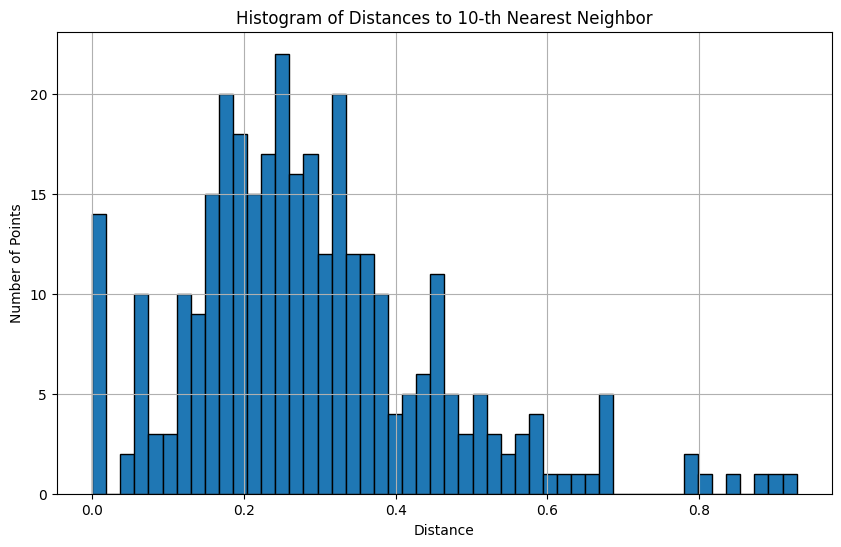

In [23]:
#from sklearn.neighbors import NearestNeighbors
#import matplotlib.pyplot as plt

# Define 'n' for the n-th nearest neighbor
n_neighbors = 10  # You can change this value

# Create a NearestNeighbors object
neigh = skl.neighbors.NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean") # +1 because the point itself is included
neigh.fit(X)

# Find the distances and indices of the nearest neighbors
distances, indices = neigh.kneighbors(X)

# The distance to the n-th nearest neighbor will be at index 'n_neighbors'
# (since distances are sorted and the first distance is to itself, index 0)
distances_to_nth_neighbor = distances[:, n_neighbors]

#print(f"Distances to the {n_neighbors}-th nearest neighbor:")
#print(distances_to_nth_neighbor)

# Plotting the histogram of distances to the n-th nearest neighbor
plt.figure(figsize=(10, 6))
plt.hist(distances_to_nth_neighbor, bins=50, edgecolor='black')
plt.title(f'Histogram of Distances to {n_neighbors}-th Nearest Neighbor')
plt.xlabel('Distance')
plt.ylabel('Number of Points')
plt.grid(True)
plt.show()

## Funciones para el pipeline del DBScan

In [24]:
from sklearn import metrics
from sklearn.cluster import DBSCAN

def perform_dbscan(X, eps_value, min_samples_value):
    """Performs DBSCAN clustering and prints basic cluster information."""
    dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
    clusters = dbscan.fit_predict(X)

    print("DBSCAN Cluster Labels:")
    print(np.unique(clusters))

    num_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    print(f"Number of clusters found: {num_clusters}")
    print(f"Number of noise points (label -1): {list(clusters).count(-1)}")
    return clusters

def reorder_and_visualize_clusters(ground_truth, clusters):
    """Reorders cluster labels to align with ground truth and visualizes the contingency matrix."""
    contingency_matrix = pd.crosstab(ground_truth, clusters)

    remap_dict = {}
    used_ground_truth_labels = set()
    next_available_label = 0

    for original_cluster_label in sorted(np.unique(clusters)):
        if original_cluster_label == -1:
            remap_dict[original_cluster_label] = -1
            continue

        max_overlap_gt = None
        max_overlap_count = -1

        if original_cluster_label in contingency_matrix.columns:
            for gt_label in contingency_matrix.index:
                count = contingency_matrix.loc[gt_label, original_cluster_label]
                if count > max_overlap_count:
                    max_overlap_count = count
                    max_overlap_gt = gt_label

        if max_overlap_gt is not None and max_overlap_gt not in used_ground_truth_labels:
            remap_dict[original_cluster_label] = max_overlap_gt
            used_ground_truth_labels.add(max_overlap_gt)
        else:
            while next_available_label in used_ground_truth_labels or next_available_label in remap_dict.values():
                next_available_label += 1
            remap_dict[original_cluster_label] = next_available_label
            used_ground_truth_labels.add(next_available_label)

    clusters_reordered = np.array([remap_dict[label] for label in clusters])

    print("Original Cluster Labels:", np.unique(clusters))
    print("Reordered Cluster Labels (aligned to ground truth where possible):", np.unique(clusters_reordered))

    contingency_matrix_reordered = pd.crosstab(ground_truth, clusters_reordered)

    plt.figure(figsize=(10, 8))
    sns.heatmap(contingency_matrix_reordered, annot=True, fmt='d', cmap='viridis')
    plt.title('Contingency Matrix (Clusters Reordered)')
    plt.xlabel('Reordered Cluster Labels')
    plt.ylabel('Ground Truth Labels')
    plt.show()

    return clusters_reordered

def calculate_clustering_metrics(ground_truth, clusters):
    """Calculates and prints clustering metrics."""
    print("\nClustering Metrics:")
    print(f"Rand Index: {metrics.rand_score(ground_truth, clusters)}")
    print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(ground_truth, clusters)}")
    print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(ground_truth, clusters)}")

def run_full_clustering_pipeline(X, ground_truth, eps_value, min_samples_value):
    """Runs the complete clustering analysis pipeline."""
    print("\n--- Running Full Clustering Pipeline ---")
    # 1. Perform DBSCAN
    clusters = perform_dbscan(X, eps_value, min_samples_value)

    # 2. Reorder clusters and visualize
    clusters_reordered = reorder_and_visualize_clusters(ground_truth, clusters)

    # 3. Calculate metrics using original clusters
    calculate_clustering_metrics(ground_truth, clusters)
    print("--- Pipeline Finished ---")
    return clusters, clusters_reordered



## Selección del punto de inflexión usando el método del codo

/tmp/ipykernel_3132/251784567.py:55: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_from_line = np.abs(np.cross(line_vec, p1 - all_points)) / line_vec_norm
/tmp/ipykernel_3132/251784567.py:55: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_from_line = np.abs(np.cross(line_vec, p1 - all_points)) / line_vec_norm
/tmp/ipykernel_3132/251784567.py:55: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_from_line = np.abs(np.cross(line_vec, p1 - all_points)) / line_vec_norm
/tmp/ipykernel_3132/251784567.py:55: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_from_line = np.abs(np.cross(line

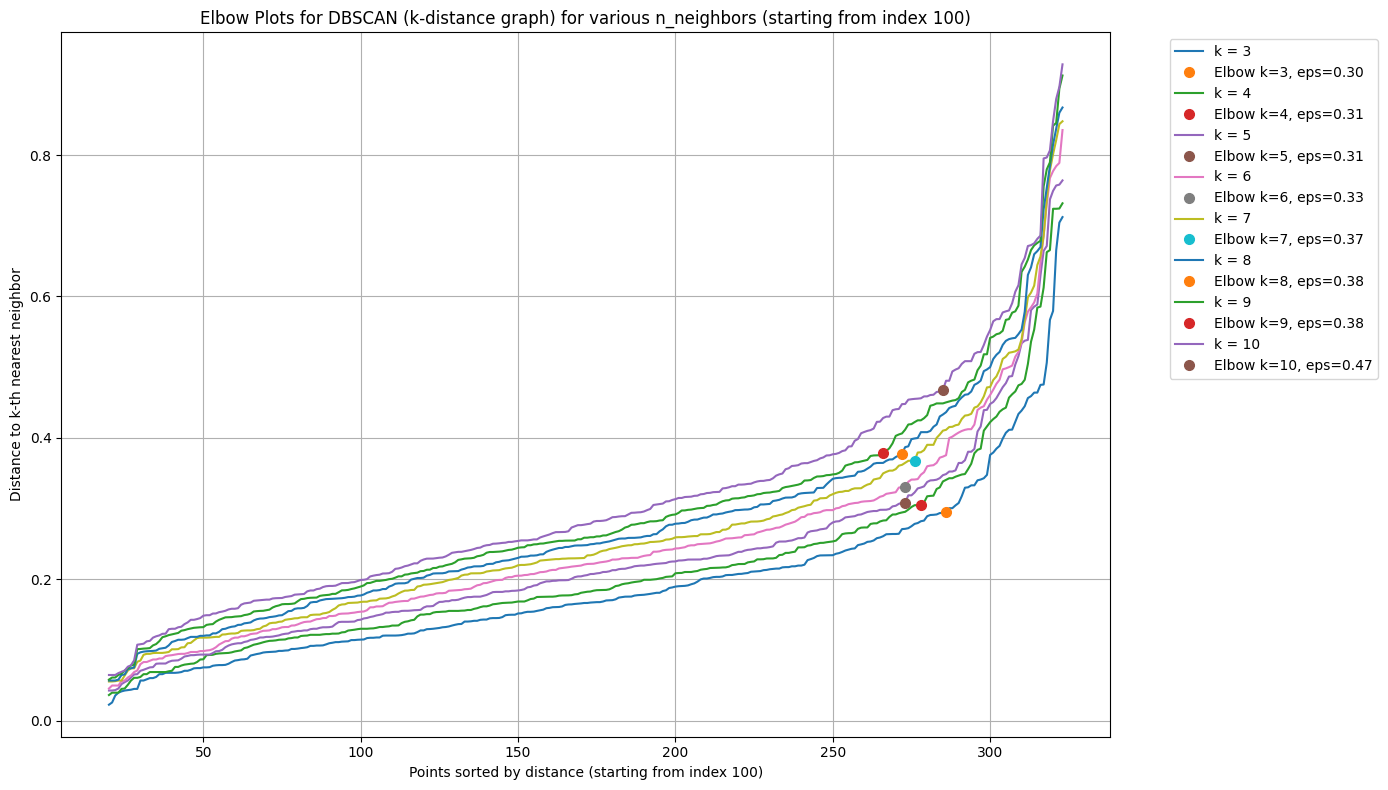

In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.neighbors import NearestNeighbors

plt.figure(figsize=(14, 8))
plt.title('Elbow Plots for DBSCAN (k-distance graph) for various n_neighbors (starting from index 100)')
plt.xlabel('Points sorted by distance (starting from index 100)')
plt.ylabel('Distance to k-th nearest neighbor')
plt.grid(True)

# Iterate through n_neighbors from 5 to 20, incrementing by 3
for n_neighbors_val in range(3, 11, 1):
    # Create a NearestNeighbors object
    neigh = skl.neighbors.NearestNeighbors(n_neighbors=n_neighbors_val + 1, metric="euclidean")
    neigh.fit(X)

    # Find the distances and indices of the nearest neighbors
    distances, _ = neigh.kneighbors(X)

    # The distance to the n-th nearest neighbor will be at index 'n_neighbors_val'
    distances_to_nth_neighbor = distances[:, n_neighbors_val]

    # Sort the distances in ascending order
    sorted_distances = np.sort(distances_to_nth_neighbor, axis=None)

    # --- Apply the user's request to start from index 100 ---
    start_index = 20
    if len(sorted_distances) > start_index:
        sliced_distances = sorted_distances[start_index:]
        # Adjust the x-axis for plotting to reflect the slicing
        x_axis_values = np.arange(len(sliced_distances)) + start_index
    else:
        print(f"Warning: Not enough points for n_neighbors_val={n_neighbors_val} to start from index {start_index}")
        continue

    # Plotting the elbow curve
    plt.plot(x_axis_values, sliced_distances, label=f'k = {n_neighbors_val}')

    # --- Heuristic to find the 'elbow' point for the current curve ---
    n_points = len(sliced_distances)
    if n_points > 1: # Ensure there are enough points for elbow detection
        all_points = np.array([np.arange(n_points), sliced_distances]).T

        # Get the first and last points
        p1 = all_points[0]
        p2 = all_points[-1]

        # Calculate the vector from p1 to p2
        line_vec = p2 - p1
        line_vec_norm = np.linalg.norm(line_vec)

        # Handle the case where line_vec_norm is zero or very small
        if line_vec_norm > 1e-9: # Use a small epsilon to avoid division by zero
            # Calculate the distance from each point to the line p1-p2
            distances_from_line = np.abs(np.cross(line_vec, p1 - all_points)) / line_vec_norm

            # Find the index of the point with the maximum distance (within the sliced array)
            elbow_idx_sliced = np.argmax(distances_from_line)

            # Map the elbow_idx back to the original index for plotting
            elbow_x_original = x_axis_values[elbow_idx_sliced]
            elbow_y = sliced_distances[elbow_idx_sliced]

            # Mark the elbow point on the plot
            plt.plot(elbow_x_original, elbow_y, 'o', markersize=7,
                     label=f'Elbow k={n_neighbors_val}, eps={elbow_y:.2f}')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid obscuring plots
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Aplicación del pipeline para diferentes valores de épsilon y MinPts


--- Running Full Clustering Pipeline ---
DBSCAN Cluster Labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Number of clusters found: 14
Number of noise points (label -1): 17
Original Cluster Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Reordered Cluster Labels (aligned to ground truth where possible): [-1  0  1  2  3  4  5  6  7  8  9 12 13 15 16]


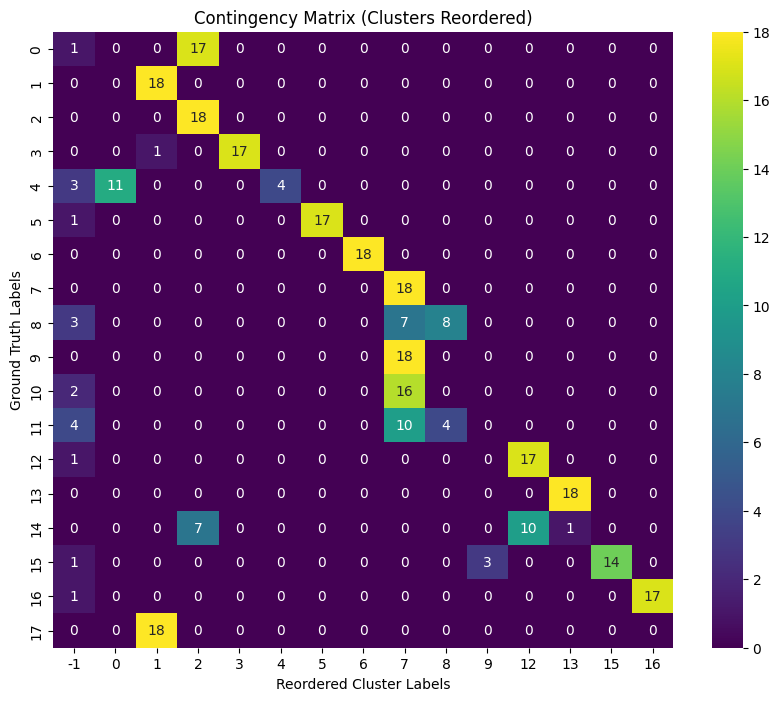


Clustering Metrics:
Rand Index: 0.9301112257768605
Adjusted Rand Index: 0.5129024795474142
Adjusted Mutual Information: 0.7626521154941537
--- Pipeline Finished ---


In [26]:
# --- Example Usage of the Pipeline Function ---

# Assuming X, ground_truth, eps_value, and min_samples_value are defined from previous cells
# For demonstration, using the values determined previously:
eps_value = 0.30
min_samples_value = 3

# Run the full pipeline
clusters_result, clusters_reordered_result = run_full_clustering_pipeline(X, ground_truth, eps_value, min_samples_value)


--- Running Full Clustering Pipeline ---
DBSCAN Cluster Labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Number of clusters found: 14
Number of noise points (label -1): 18
Original Cluster Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Reordered Cluster Labels (aligned to ground truth where possible): [-1  0  1  2  3  4  5  6  7  8 10 12 13 15 16]


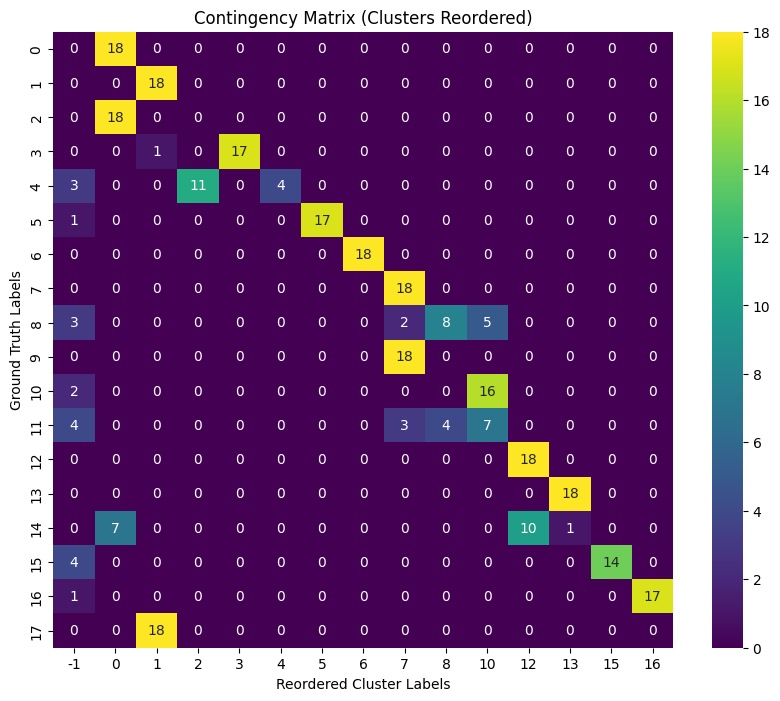


Clustering Metrics:
Rand Index: 0.950693727783511
Adjusted Rand Index: 0.6063978416919593
Adjusted Mutual Information: 0.7911588721002614
--- Pipeline Finished ---


In [27]:
# --- Example Usage of the Pipeline Function ---

# Assuming X, ground_truth, eps_value, and min_samples_value are defined from previous cells
# For demonstration, using the values determined previously:
eps_value = 0.31
min_samples_value = 4

# Run the full pipeline
clusters_result, clusters_reordered_result = run_full_clustering_pipeline(X, ground_truth, eps_value, min_samples_value)


--- Running Full Clustering Pipeline ---
DBSCAN Cluster Labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Number of clusters found: 14
Number of noise points (label -1): 29
Original Cluster Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Reordered Cluster Labels (aligned to ground truth where possible): [-1  0  1  3  4  5  6  7  8 10 12 13 15 16 17]


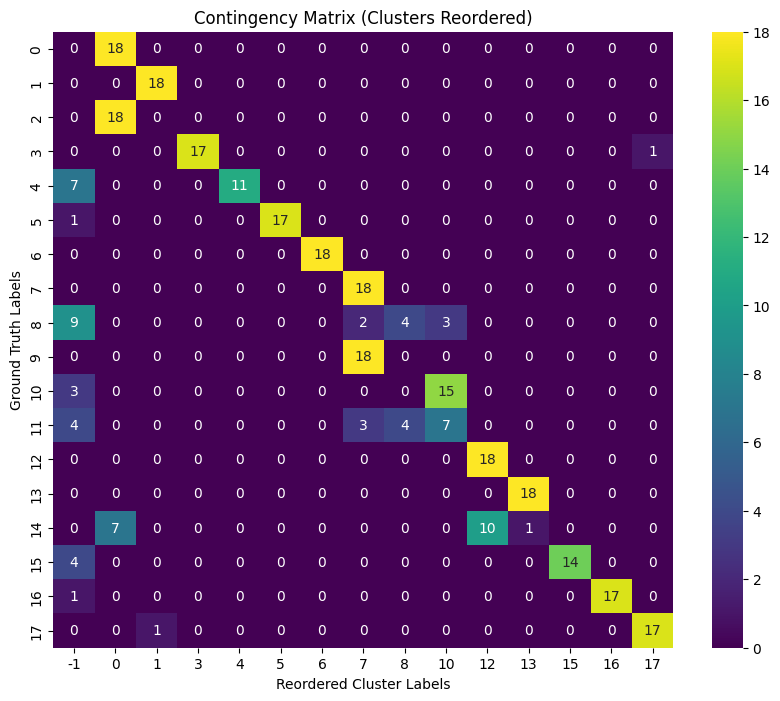


Clustering Metrics:
Rand Index: 0.9541910331384016
Adjusted Rand Index: 0.6234715390021083
Adjusted Mutual Information: 0.799275584732765
--- Pipeline Finished ---


In [28]:
# --- Example Usage of the Pipeline Function ---

# Assuming X, ground_truth, eps_value, and min_samples_value are defined from previous cells
# For demonstration, using the values determined previously:
eps_value = 0.31
min_samples_value = 5

# Run the full pipeline
clusters_result, clusters_reordered_result = run_full_clustering_pipeline(X, ground_truth, eps_value, min_samples_value)